In [1]:
!pip install transformers diffusers

In [20]:
import torch
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw

#google drive
from google.colab import drive
drive.mount('/content/drive')

device = "cuda" if torch.cuda.is_available() else "cpu"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:
def run_grounding_dino_pipeline(img_dir, results_save_dir="./annotated_imgs", text_prompt='wood-staves', device=device, visualize=True, limit=5):
  processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
  model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base").to(device)
  count=0
  os.makedirs(results_save_dir, exist_ok=True)

  results = []
  for img_name in os.listdir(img_dir):
    if count == limit:
      break
    count += 1

    with Image.open(os.path.join(img_dir, img_name)) as image:
      inputs = processor(text=text_prompt, images=image, return_tensors="pt").to(device)
      with torch.no_grad():
        outputs = model(**inputs)

        detections = processor.post_process_grounded_object_detection(
          outputs,
          inputs.input_ids,
          threshold=0.1, #for box threshold
          text_threshold=0.9, #how closely adheres to the provided text prompt
          target_sizes=[image.size[::-1]]
        )

        detections = detections[0]

        draw = ImageDraw.Draw(image)
        for box, label, score in zip(detections["boxes"], detections["labels"], detections["scores"]):
            box = [int(x) for x in box.tolist()]
            draw.rectangle(box, outline="red", width=3)
            draw.text((box[0], box[1] - 10), f"{label} ({score:.2f})", fill="red")

        if visualize:
            plt.figure(figsize=(8, 8))
            plt.imshow(image)
            plt.axis("off")
            plt.title(f"{img_name} - '{text_prompt}'")
            plt.show()

        save_path = os.path.join(results_save_dir, f"annotated_{img_name}.jpeg")
        image.save(save_path)
        results.append(detections)
  return results


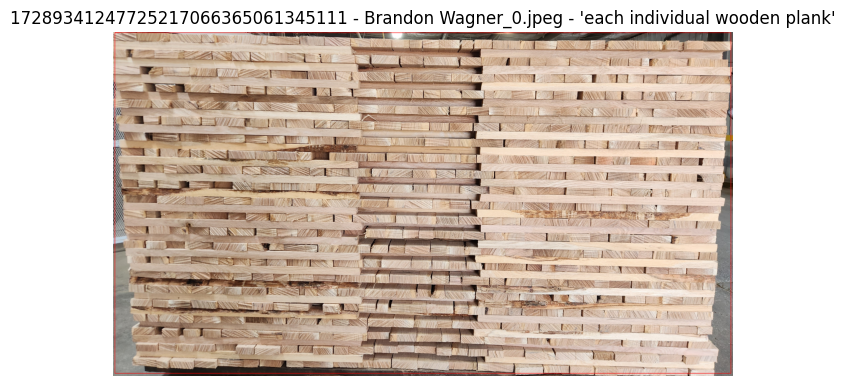

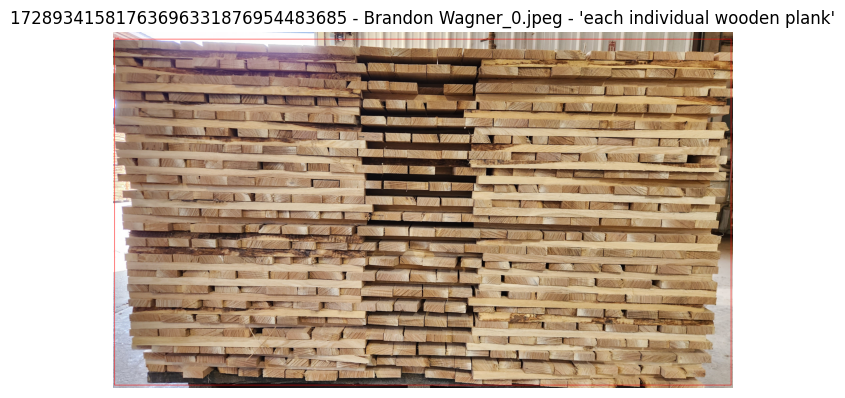

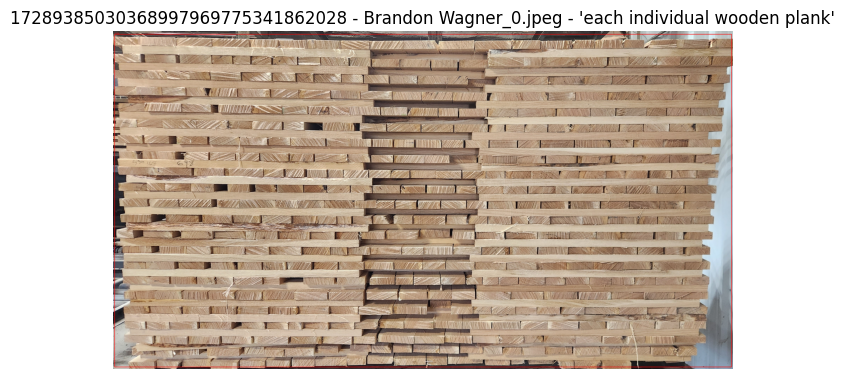

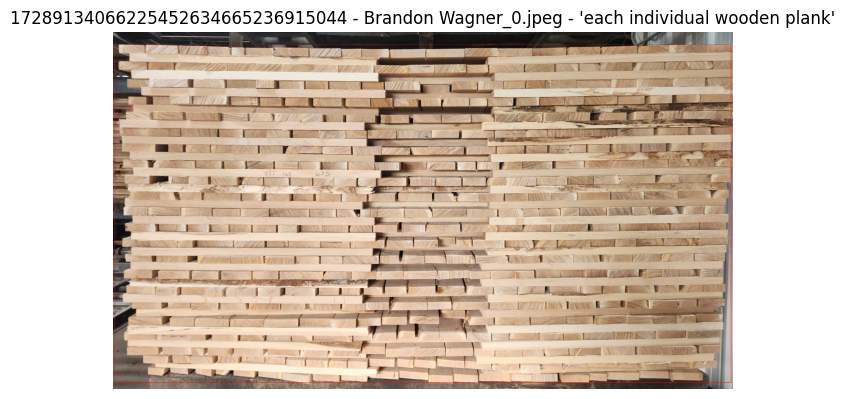

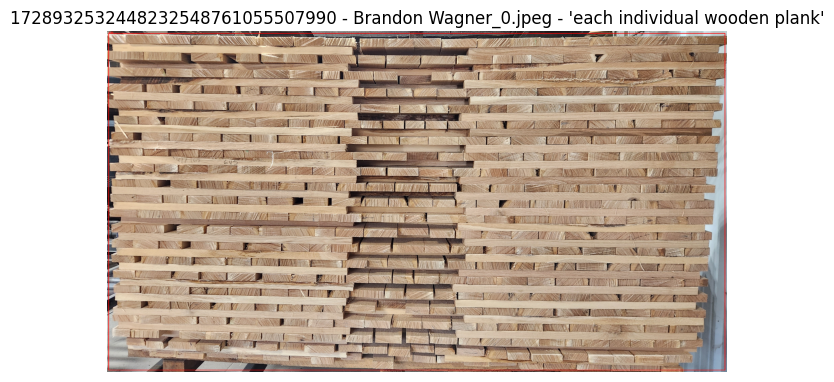

In [45]:
results = run_grounding_dino_pipeline(img_dir="",
                                      text_prompt="each individual wooden plank")

In [44]:
for a_result in results:
  print(a_result)

{'scores': tensor([0.6316, 0.5189, 0.2194, 0.2603, 0.2100, 0.1779, 0.1483, 0.1304, 0.1062],
       device='cuda:0'), 'boxes': tensor([[  13.8912,   21.1374, 3707.6035, 2057.4470],
        [  12.1326,   20.4553, 3707.5347, 2058.3091],
        [  14.4091,   19.5813, 3709.2485, 2059.7063],
        [2173.9573,   50.5592, 3710.2471, 2062.3940],
        [2173.4187,   48.6632, 3709.6321, 2064.7808],
        [  13.3398,   17.3526, 1509.4873, 2048.1316],
        [  13.2107,   13.9133, 1508.6606, 2048.9998],
        [1441.9576,   37.1709, 2216.8782, 2047.5641],
        [1437.9731,   24.5951, 2213.7170, 2053.2471]], device='cuda:0'), 'text_labels': ['', '', '', '', '', '', '', '', ''], 'labels': ['', '', '', '', '', '', '', '', '']}
{'scores': tensor([0.6265, 0.5155, 0.2870, 0.2318, 0.2149, 0.2437, 0.1975, 0.1313, 0.1056],
       device='cuda:0'), 'boxes': tensor([[  10.7117,   51.4798, 3683.8369, 2112.7390],
        [   9.6135,   50.3756, 3684.3345, 2112.8335],
        [2104.3044,   97.8520, 368